<a href="https://colab.research.google.com/github/Pradeep1694/Capstone-Project/blob/main/Capstone_Project_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd

df = pd.read_csv("cleaned_data.csv")

x = df.drop(columns=["discounted_price"])

y_reg = df["discounted_price"]

y_clf =(y_reg >= y_reg.median()).astype(int)

X = df.drop(columns=["discounted_price"])

print("Feature Matrix (X):", X.shape)
print("Regression Target(y_reg):", y_reg.shape)
print("Classification Target (y_clf):", y_clf.shape)


Feature Matrix (X): (1465, 15)
Regression Target(y_reg): (1465,)
Classification Target (y_clf): (1465,)


In [56]:

X = df.drop(columns=["discounted_price"])

# Encode Categorical Columns
drop_cols = [
    "product_id",
    "product_name",
    "about_product",
    "user_id",
    "user_name",
    "review_id",
    "review_title",
    "review_content",
    "img_link",
    "product_link"
]

X = X.drop(columns=drop_cols)

X = pd.get_dummies(X,columns=["category"], drop_first=True)

print("shape after encoding:", X.shape)
X.head()

shape after encoding: (1465, 214)


,actual_price,discount_percentage,rating,rating_count,category_Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters,category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets,category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones,category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers,category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|Webcams&VoIPEquipment|Webcams,category_Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors,...,"category_OfficeProducts|OfficePaperProducts|Paper|Stationery|Notebooks,WritingPads&Diaries|CompositionNotebooks","category_OfficeProducts|OfficePaperProducts|Paper|Stationery|Notebooks,WritingPads&Diaries|Notepads&MemoBooks","category_OfficeProducts|OfficePaperProducts|Paper|Stationery|Notebooks,WritingPads&Diaries|WireboundNotebooks","category_OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|BottledInk","category_OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|FountainPens","category_OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens","category_OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|LiquidInkRollerballPens","category_OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|RetractableBallpointPens","category_OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|StickBallpointPens",category_Toys&Games|Arts&Crafts|Drawing&PaintingSupplies|ColouringPens&Markers
0,1099.0,64.0,4.2,24269.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,349.0,43.0,4.0,43994.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1899.0,90.0,3.9,7928.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,699.0,53.0,4.2,94363.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,399.0,61.0,4.2,16905.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_reg_train, y_reg_test =train_test_split(X, y_reg, test_size=0.2,
                                                           random_state=42)

scaler = StandardScaler()

x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.transform(x_test)

print("x_train_scaled:", x_train_scaler.shape)
print("x_test_scaled:", x_test_scaler.shape)

print("y_reg_train:", y_reg_train.shape)
print("y_reg_test:", y_reg_test.shape)


x_train_scaled: (1172, 214)
x_test_scaled: (293, 214)
y_reg_train: (1172,)
y_reg_test: (293,)


In [58]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

x_train = x_train.fillna(x_train.median(numeric_only=True))
x_test = x_test.fillna(x_test.median(numeric_only=True))

scaler = StandardScaler()

x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.transform(x_test)

lr = LinearRegression()
lr.fit(x_train_scaler, y_reg_train)

y_pred_lr =lr.predict(x_test_scaler)

mse_lr = mean_squared_error(y_reg_test, y_pred_lr)
r2_lr = r2_score(y_reg_test, y_pred_lr)

print("Linear Regression Metrics:")
print(f"MSE:", mse_lr)
print(f"R2 Score:", r2_lr)


Linear Regression Metrics:
MSE: 2845366.60870538
R2 Score: 0.9437415844271674


In [59]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coeffient": lr.coef_
})
print(coef_df)

                                               Feature    Coeffient
0                                         actual_price  6383.609776
1                                  discount_percentage -1018.208043
2                                               rating  -150.680868
3                                         rating_count    26.613793
4    category_Computers&Accessories|Accessories&Per...    21.119739
..                                                 ...          ...
209  category_OfficeProducts|OfficePaperProducts|Pa...   -67.311171
210  category_OfficeProducts|OfficePaperProducts|Pa...   -58.247925
211  category_OfficeProducts|OfficePaperProducts|Pa...     0.000000
212  category_OfficeProducts|OfficePaperProducts|Pa...   -54.700373
213  category_Toys&Games|Arts&Crafts|Drawing&Painti...   -47.078799

[214 rows x 2 columns]


In [60]:
ridge = Ridge(alpha=1.0)

ridge.fit(x_train_scaler, y_reg_train)

y_pred_ridge = ridge.predict(x_test_scaler)

mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)

print("Ridge Regression")
print("MSE:", mse_ridge)
print("R2 Score:", r2_ridge)

Ridge Regression
MSE: 2834725.6174100926
R2 Score: 0.9439519774600249


In [61]:
comparion = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse_lr, mse_ridge],
    "R2 Score": [r2_lr, r2_ridge]
})
print(comparion)

               Model           MSE  R2 Score
0  Linear Regression  2.845367e+06  0.943742
1   Ridge Regression  2.834726e+06  0.943952


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


x_train, x_test, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.2,
                                                           random_state=42)
print("class distribution:")
print(y_clf_train.value_counts())

class_percent = y_clf_train.value_counts(normalize=True) * 100
print(class_percent)

if class_percent.min() < 35:
  print("Imbalanced Dataset")
else:
  print("Balanced Dataset")


class distribution:
discounted_price
1    597
0    575
Name: count, dtype: int64
discounted_price
1    50.938567
0    49.061433
Name: proportion, dtype: float64
Balanced Dataset


In [63]:
#Logistic Regression

from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(x_train_scaler,y_clf_train)

#Predictions
y_pred = log_model.predict(x_test_scaler)
y_prob = log_model.predict_proba(x_test_scaler)

print("\nAccuracy:", accuracy_score(y_clf_test, y_pred))
print("Precision:", precision_score(y_clf_test, y_pred))
print("Recall:", recall_score(y_clf_test, y_pred))
print("F1 Score:", f1_score(y_clf_test, y_pred))
#confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_clf_test, y_pred))

print("\nClassification report:")
print(classification_report(y_clf_test, y_pred))


Accuracy: 0.9044368600682594
Precision: 0.9416058394160584
Recall: 0.8657718120805369
F1 Score: 0.9020979020979021
Confusion Matrix:
 [[136   8]
 [ 20 129]]

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91       144
           1       0.94      0.87      0.90       149

    accuracy                           0.90       293
   macro avg       0.91      0.91      0.90       293
weighted avg       0.91      0.90      0.90       293



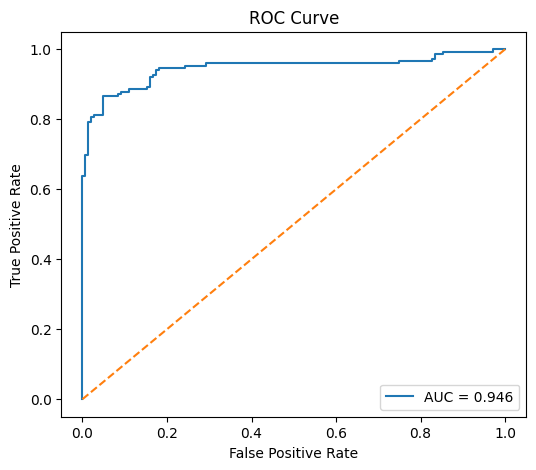

AUC Score: 0.9457028337061895


In [64]:
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_clf_test, y_prob[:, 1])
roc_auc = roc_auc_score(y_clf_test, y_prob[:, 1])

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve.png")
plt.show()

print("AUC Score:", roc_auc)

In [65]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.10]

results = []

for threshold in thresholds:
  y_pred_threshold = (y_prob[:, 1] >= threshold).astype(int)

  precision = precision_score(y_clf_test, y_pred_threshold)
  recall = recall_score(y_clf_test, y_pred_threshold)
  f1 = f1_score(y_clf_test, y_pred_threshold)

  results.append([threshold, precision, recall, f1])


threshold_df = pd.DataFrame(results,columns=["Threshold", "Precision", "Recall", "F1 Score"])
print(threshold_df)

   Threshold  Precision    Recall  F1 Score
0        0.3   0.855346  0.912752  0.883117
1        0.4   0.891892  0.885906  0.888889
2        0.5   0.941606  0.865772  0.902098
3        0.6   0.946565  0.832215  0.885714
4        0.7   0.982906  0.771812  0.864662
5        0.1   0.655963  0.959732  0.779292


In [66]:
log_reg_c001 = LogisticRegression(C=0.01, max_iter=1000, random_state=42)

log_reg_c001.fit(x_train_scaler, y_clf_train)

y_pred_c001 = log_reg_c001.predict(x_test_scaler)
y_prob_c001 = log_reg_c001.predict_proba(x_test_scaler)

precision_c001 = precision_score(y_clf_test, y_pred_c001)
recall_c001 = recall_score(y_clf_test, y_pred_c001)
aue_c001 = roc_auc_score(y_clf_test, y_prob_c001[:, 1])

print("precision:", precision_c001)
print("recall:", recall_c001)
print("AUC:", aue_c001)

precision: 0.8686131386861314
recall: 0.7986577181208053
AUC: 0.9088832960477257


In [67]:
comparison = pd.DataFrame({
    "Model": ["c = 1.0", "C=0.01"],
    "Precision": [precision_score(y_clf_test, y_pred), precision_c001],
    "Recall": [recall_score(y_clf_test, y_pred), recall_c001],
    "AUC": [roc_auc_score(y_clf_test,y_prob[:,1]), aue_c001]
})

print(comparison)

     Model  Precision    Recall       AUC
0  c = 1.0   0.941606  0.865772  0.945703
1   C=0.01   0.868613  0.798658  0.908883


In [68]:
import numpy as np
from sklearn.metrics import roc_auc_score

n_bootstrap = 500
auc_scores_c1 = []
auc_scores_c001 = []

for i in range(n_bootstrap):
  bootstrap_indices = np.random.choice(len(y_clf_test), len(y_clf_test), replace=True)

  if len(np.unique(y_clf_test.iloc[bootstrap_indices])) < 2:
    continue

  # Calculate AUC for the C=1.0 model (original log_model)
  auc_c1 = roc_auc_score(y_clf_test.iloc[bootstrap_indices], y_prob[bootstrap_indices, 1])
  auc_scores_c1.append(auc_c1)

  # Calculate AUC for the C=0.01 model
  auc_c001 = roc_auc_score(y_clf_test.iloc[bootstrap_indices], y_prob_c001[bootstrap_indices, 1])
  auc_scores_c001.append(auc_c001)


lower_c1 = np.percentile(auc_scores_c1, 2.5)
upper_c1 = np.percentile(auc_scores_c1, 97.5)

print("Mean AUC:", np.mean(auc_scores_c1))
print("95% Confidence Interval:")
print("Lower Bound C=1.0:", lower_c1)
print("Upper Bound C=1.0:", upper_c1)

lower_c001 = np.percentile(auc_scores_c001, 2.5)
upper_c001 = np.percentile(auc_scores_c001, 97.5)

print("\nMean AUC:", np.mean(auc_scores_c001))
print("95% Confidence Interval:")
print("Lower Bound C=0.01:", lower_c001)
print("Upper Bound C=0.01:", upper_c001)

Mean AUC: 0.9458187445905051
95% Confidence Interval:
Lower Bound C=1.0: 0.9150891843675938
Upper Bound C=1.0: 0.9725852758352759

Mean AUC: 0.9089587971519304
95% Confidence Interval:
Lower Bound C=0.01: 0.8733925076880067
Upper Bound C=0.01: 0.9418220117587583
